<a href="https://colab.research.google.com/github/ankitta-singh/machinelearning/blob/main/Ridge%20and%20Lasso%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques.zip


In [3]:
import zipfile as zipfiles
with zipfiles.ZipFile("house-prices-advanced-regression-techniques.zip","r") as zip_ref:
  zip_ref.extractall("house data")

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [8]:
df =pd.read_csv("house data/train.csv")

In [9]:
X=df.drop('SalePrice',axis=1)
y=df['SalePrice']

In [10]:
X= pd.get_dummies(X,drop_first=True)
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.30,random_state=42)

In [12]:
ridge_regression=Ridge()

In [15]:
parameters={'alpha':[1,2,5,10,50,60,70,80,90]}
ridgecv=GridSearchCV(ridge_regression,parameters,scoring='neg_mean_squared_error',cv=5)
ridgecv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 50, 60, 70, 80, 90]},
             scoring='neg_mean_squared_error')

In [16]:
print(ridgecv.best_params_)
print(ridgecv.best_score_)

{'alpha': 5}
-1489234266.1491253


In [17]:
ridge_pred=ridgecv.predict(X_test)

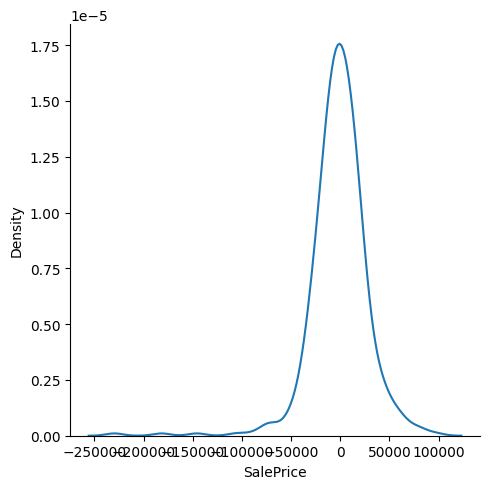

In [21]:
import seaborn as sns
sns.displot(ridge_pred-y_test,kind='kde')

In [23]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_test,ridge_pred))
from sklearn.metrics import r2_score
print(r2_score(y_test,ridge_pred))

863874191.7894578
0.8762019798838052


In [26]:
## lasso regression
from sklearn.linear_model import Lasso
lasso=Lasso()

In [27]:
parameters={'alpha':[1,2,5,10,50,60,70,80,90]}
lassocv=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)
lassocv.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.527e+11, tolerance: 4.742e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.107e+11, tolerance: 4.840e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.225e+11, tolerance: 4.842e

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 50, 60, 70, 80, 90]},
             scoring='neg_mean_squared_error')

In [28]:
print(lassocv.best_params_)
print(lassocv.best_score_)

{'alpha': 90}
-1690683129.409977


In [29]:
lasso_pred=lassocv.predict(X_test)

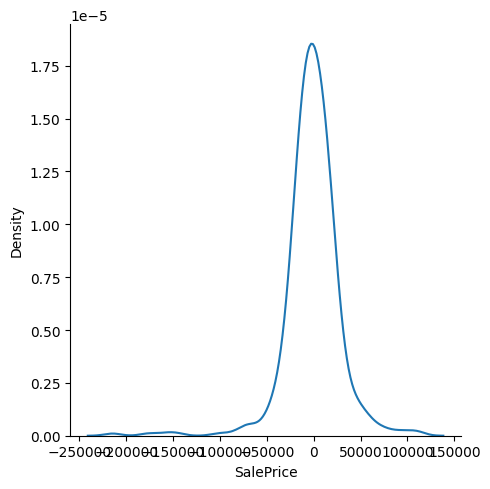

In [30]:
import seaborn as sns
sns.displot(lasso_pred-y_test,kind='kde')